# 04 — DataLoader & Datasets: Feeding Real Data into Your Model

**Project:** AutoGrader  
**Purpose:** Learn how PyTorch loads, batches, and shuffles data for training  
**Covers:** Dataset class, DataLoader, batching, shuffling, custom datasets, train/val/test splits

---

## Why DataLoader?

In notebook 03, you passed the entire dataset to the model at once (`model(X_train)`).  
That works for 200 rows. It doesn't work for 200,000 rows — you'd run out of memory.

DataLoader solves this by feeding data in **batches** — small chunks at a time.  
It also handles **shuffling** (so the model doesn't learn the order of data) and  
**parallel loading** (so your GPU isn't waiting for data).

Think of it like a conveyor belt: your model stands at the end, and DataLoader  
keeps feeding it trays of data, one batch at a time.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.5.1


---
## Section 1 — TensorDataset: the quick way

In [4]:
# When your data already fits in memory as tensors, use TensorDataset
# It zips X and y together so they stay aligned

# Synthetic data: 500 students, 4 features, 1 grade
X = torch.randn(500, 4)
y = torch.sigmoid(0.6 * X[:, 0] + 0.4 * X[:, 2]).unsqueeze(1)

dataset = TensorDataset(X, y)

print(f"Dataset size: {len(dataset)}")

# Each item is a (X_sample, y_sample) tuple
sample_x, sample_y = dataset[0]
print(f"Single sample X shape: {sample_x.shape}")  # [4]
print(f"Single sample y shape: {sample_y.shape}")  # [1]

Dataset size: 500
Single sample X shape: torch.Size([4])
Single sample y shape: torch.Size([1])


In [5]:
# --- Wrap dataset in a DataLoader ---

loader = DataLoader(
    dataset,
    batch_size=32,    # 32 samples per batch
    shuffle=True,     # shuffle every epoch
    num_workers=0     # 0 = load on main process (safe for notebooks)
)

print(f"Total batches per epoch: {len(loader)}")  # 500 / 32 = ~16 batches

# Peek at one batch
batch_X, batch_y = next(iter(loader))
print(f"Batch X shape: {batch_X.shape}")   # [32, 4]
print(f"Batch y shape: {batch_y.shape}")   # [32, 1]

Total batches per epoch: 16
Batch X shape: torch.Size([32, 4])
Batch y shape: torch.Size([32, 1])


In [6]:
# --- How DataLoader fits into the training loop ---
# You iterate over loader instead of passing X_train directly

print("Showing first 3 batches:\n")
for batch_idx, (batch_X, batch_y) in enumerate(loader):
    print(f"  Batch {batch_idx}: X={batch_X.shape}, y={batch_y.shape}")
    if batch_idx == 2:
        print("  ... and so on for all batches")
        break

Showing first 3 batches:

  Batch 0: X=torch.Size([32, 4]), y=torch.Size([32, 1])
  Batch 1: X=torch.Size([32, 4]), y=torch.Size([32, 1])
  Batch 2: X=torch.Size([32, 4]), y=torch.Size([32, 1])
  ... and so on for all batches


---
## Section 2 — Train / Validation / Test Split

In [7]:
# Standard split: 70% train, 15% validation, 15% test
# Validation = tune hyperparameters during training
# Test = final honest evaluation (touch it only once)

total = len(dataset)          # 500
n_train = int(0.70 * total)   # 350
n_val   = int(0.15 * total)   # 75
n_test  = total - n_train - n_val  # 75

train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test])

print(f"Train size:      {len(train_set)}")
print(f"Validation size: {len(val_set)}")
print(f"Test size:       {len(test_set)}")

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False)  # no shuffle for eval
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train size:      350
Validation size: 75
Test size:       75

Train batches: 11
Val batches:   3
Test batches:  3


---
## Section 3 — Custom Dataset class

When your data isn't already tensors (CSV files, text, images), you build a custom Dataset.

In [8]:
# Custom Dataset — 3 rules:
#   1. Inherit from torch.utils.data.Dataset
#   2. Implement __len__  → returns total number of samples
#   3. Implement __getitem__ → returns one sample by index

class StudentAnswerDataset(Dataset):
    """
    Simulates an AutoGrader dataset:
    - answer_embeddings: vector representation of student answers
    - grades: the correct grade for each answer
    """
    def __init__(self, n_samples=300, embed_dim=64):
        # In a real project, you'd load from CSV/DB here
        self.embeddings = torch.randn(n_samples, embed_dim)
        self.grades     = torch.sigmoid(
            self.embeddings[:, 0] + self.embeddings[:, 1]
        ).unsqueeze(1)
        self.n_samples  = n_samples

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        return self.embeddings[idx], self.grades[idx]


answer_dataset = StudentAnswerDataset(n_samples=300, embed_dim=64)
print(f"Dataset size: {len(answer_dataset)}")

emb, grade = answer_dataset[0]
print(f"Embedding shape: {emb.shape}")    # [64]
print(f"Grade: {grade.item():.4f}")

Dataset size: 300
Embedding shape: torch.Size([64])
Grade: 0.3635


In [9]:
# Plug custom dataset straight into DataLoader — same as TensorDataset

answer_loader = DataLoader(answer_dataset, batch_size=16, shuffle=True)

batch_emb, batch_grade = next(iter(answer_loader))
print(f"Batch embeddings shape: {batch_emb.shape}")   # [16, 64]
print(f"Batch grades shape:     {batch_grade.shape}") # [16, 1]

Batch embeddings shape: torch.Size([16, 64])
Batch grades shape:     torch.Size([16, 1])


---
## Section 4 — Full Training Loop with DataLoader

In [10]:
# Model for 64-dim embeddings → grade
class EmbeddingGrader(nn.Module):
    def __init__(self, embed_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


# Split dataset
n = len(answer_dataset)
train_set, val_set = random_split(answer_dataset, [int(0.8*n), n - int(0.8*n)])
train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=16, shuffle=False)

model     = EmbeddingGrader(embed_dim=64)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Train batches per epoch: {len(train_loader)}")

Model parameters: 2625
Train batches per epoch: 15


In [11]:
# --- Training loop with DataLoader ---
# Same pattern as notebook 03, but now iterating over batches

n_epochs     = 30
train_losses = []
val_losses   = []

for epoch in range(n_epochs):

    # ── TRAIN ──────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0

    for batch_X, batch_y in train_loader:       # ← iterate batches
        optimizer.zero_grad()
        preds = model(batch_X)
        loss  = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── VALIDATE ───────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0.0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:     # ← iterate val batches
            preds = model(batch_X)
            loss  = criterion(preds, batch_y)
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}")

print(f"\nFinal → Train: {train_losses[-1]:.4f} | Val: {val_losses[-1]:.4f}")

Epoch   0 | Train: 0.0692 | Val: 0.0789
Epoch  10 | Train: 0.0093 | Val: 0.0236
Epoch  20 | Train: 0.0006 | Val: 0.0086

Final → Train: 0.0002 | Val: 0.0074


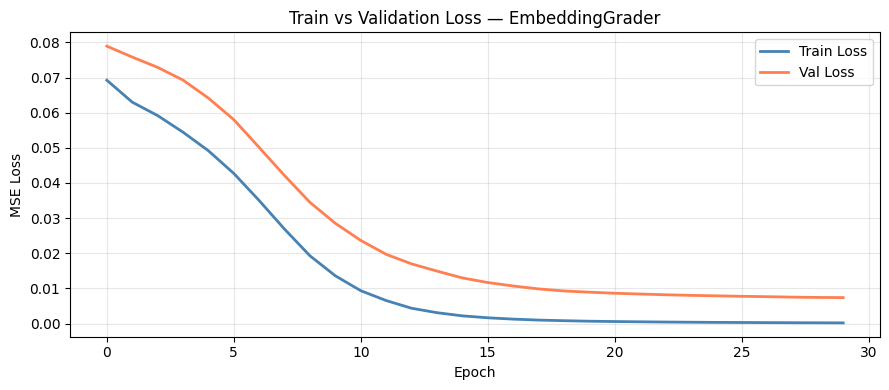

In [12]:
# Plot
plt.figure(figsize=(9, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
plt.plot(val_losses,   label='Val Loss',   color='coral',     linewidth=2)
plt.title('Train vs Validation Loss — EmbeddingGrader')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dataloader_training_curve.png', dpi=100)
plt.show()

---
## Section 5 — DataLoader Parameters You Need to Know

In [13]:
# batch_size
# How many samples per batch. Typical values: 16, 32, 64, 128.
# Larger = faster training but more memory. Smaller = more gradient updates.
# Start with 32.

# shuffle
# True for train (prevents model learning data order)
# False for val/test (order doesn't matter, reproducibility is cleaner)

# num_workers
# How many CPU processes load data in parallel.
# 0 = main process (safe in notebooks, no speedup)
# 2 or 4 = parallel loading (use in production training scripts)
# On Mac with MPS, keep at 0 to avoid multiprocessing issues

# drop_last
# If dataset size isn't divisible by batch_size, the last batch is smaller.
# drop_last=True discards it. Useful when BatchNorm is in the model.

# pin_memory
# pin_memory=True speeds up CPU→GPU transfer. Use when training on GPU.

demo_loader = DataLoader(
    answer_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    drop_last=False,
    pin_memory=False
)
print(f"Batches: {len(demo_loader)}")
print("Parameters explained above — adjust as needed per task.")

Batches: 10
Parameters explained above — adjust as needed per task.


---
## Section 6 — Quick Reference Cheatsheet

In [14]:
# ================================================================
# DATALOADER CHEATSHEET
# ================================================================

# QUICK DATASET (tensors already in memory)
# dataset = TensorDataset(X, y)

# CUSTOM DATASET
# class MyDataset(Dataset):
#     def __init__(self): ...load data...
#     def __len__(self): return n_samples
#     def __getitem__(self, idx): return X[idx], y[idx]

# SPLIT
# train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test])

# DATALOADER
# train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
# val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False)

# TRAINING LOOP WITH BATCHES
# for epoch in range(n_epochs):
#     model.train()
#     for batch_X, batch_y in train_loader:
#         optimizer.zero_grad()
#         loss = criterion(model(batch_X), batch_y)
#         loss.backward()
#         optimizer.step()
#
#     model.eval()
#     with torch.no_grad():
#         for batch_X, batch_y in val_loader:
#             val_loss = criterion(model(batch_X), batch_y)

# KEY PARAMS
# batch_size  → 32 default
# shuffle     → True for train, False for val/test
# num_workers → 0 in notebooks, 2-4 in scripts
# drop_last   → True if using BatchNorm
# pin_memory  → True when training on GPU

print("Cheatsheet loaded.")

Cheatsheet loaded.


---
## ✅ Proof Checklist

- [ ] Created a `TensorDataset` and wrapped it in a `DataLoader`
- [ ] Inspected a single batch — confirmed shapes are correct
- [ ] Split dataset into train / validation / test using `random_split`
- [ ] Built a custom `Dataset` class with `__len__` and `__getitem__`
- [ ] Ran a full training loop iterating over batches (not the whole dataset at once)
- [ ] Tracked and plotted both train loss and val loss per epoch
- [ ] Explained the key DataLoader parameters (batch_size, shuffle, num_workers)

**Next skill:** Fine-tuning a pretrained model with HuggingFace + PyTorch (`05_finetune.ipynb`)  
← This one connects directly to AutoGrader's core use case.